# Week 9 Activity – EDA of EC2 & S3

In [1]:
import pandas as pd

ec2 = pd.read_csv('./aws_resources_compute.csv')
s3 = pd.read_csv('./aws_resources_S3.csv')

ec2.head(), s3.head()

(  ResourceId ResourceType      Region  CostUSD  \
 0     i-1000          EC2   us-west-2    1.074   
 1     i-1001          EC2  ap-south-1    0.948   
 2     i-1002          EC2   us-east-1    0.190   
 3     i-1003          EC2   eu-west-1    0.381   
 4     i-1004          EC2   eu-west-1    0.306   
 
                              Tags CreationDate InstanceType    State  \
 0     Owner=Alice,Environment=Dev   2025-07-22    c5.xlarge  running   
 1     Owner=Alice,Environment=Dev   2025-05-28     r5.large  stopped   
 2  Owner=Charlie,Environment=Test   2025-06-30     m5.large  running   
 3  Owner=Charlie,Environment=Test   2025-06-14     r5.large  running   
 4     Owner=David,Environment=Dev   2025-08-24     r5.large  running   
 
    CPUUtilization  MemoryUtilization  NetworkIn_Bps  NetworkOut_Bps  
 0           68.18              70.07       987289.0        269974.0  
 1           76.62              70.36       151266.0        377907.0  
 2           85.10              18.25  

In [2]:
ec2.info()
s3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ResourceId         120 non-null    object 
 1   ResourceType       120 non-null    object 
 2   Region             120 non-null    object 
 3   CostUSD            120 non-null    float64
 4   Tags               120 non-null    object 
 5   CreationDate       120 non-null    object 
 6   InstanceType       120 non-null    object 
 7   State              120 non-null    object 
 8   CPUUtilization     120 non-null    float64
 9   MemoryUtilization  120 non-null    float64
 10  NetworkIn_Bps      120 non-null    float64
 11  NetworkOut_Bps     120 non-null    float64
dtypes: float64(5), object(7)
memory usage: 18.9+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80 entries, 0 to 79
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          -

In [3]:
ec2.describe(), s3.describe()

(          CostUSD  CPUUtilization  MemoryUtilization  NetworkIn_Bps  \
 count  120.000000      120.000000         120.000000     120.000000   
 mean     0.600908       47.674583          52.542000  482505.541667   
 std      0.341778       26.257411          25.206763  288960.083106   
 min      0.016000        6.300000          10.870000   15530.000000   
 25%      0.281500       23.970000          32.765000  212848.250000   
 50%      0.605500       48.465000          54.490000  471856.000000   
 75%      0.886500       68.575000          75.040000  722157.750000   
 max      1.196000       94.150000          89.440000  999718.000000   
 
        NetworkOut_Bps  
 count      120.000000  
 mean    477817.375000  
 std     276913.527598  
 min      21051.000000  
 25%     241872.750000  
 50%     451456.500000  
 75%     694150.000000  
 max     989970.000000  ,
           CostUSD   ObjectCount  TotalSizeGB
 count   80.000000      80.00000    80.000000
 mean   161.670375  531559.60000

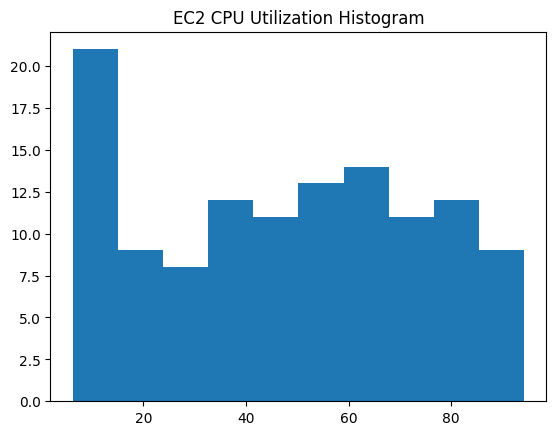

In [4]:
import matplotlib.pyplot as plt

plt.figure()
plt.hist(ec2['CPUUtilization'].dropna())
plt.title('EC2 CPU Utilization Histogram')
plt.show()

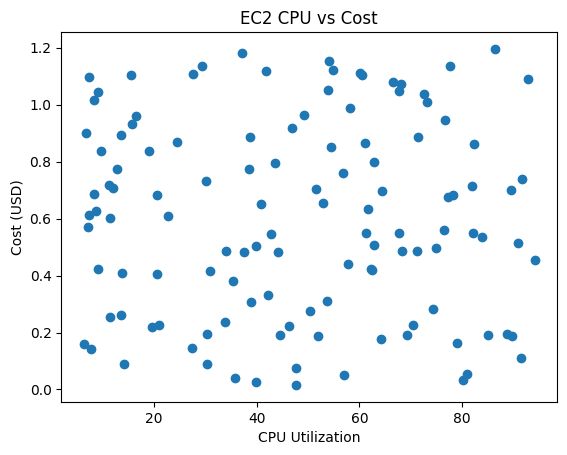

In [9]:
plt.figure()
plt.scatter(ec2['CPUUtilization'], ec2['CostUSD'])
plt.title('EC2 CPU vs Cost')
plt.xlabel('CPU Utilization')
plt.ylabel('Cost (USD)')
plt.show()

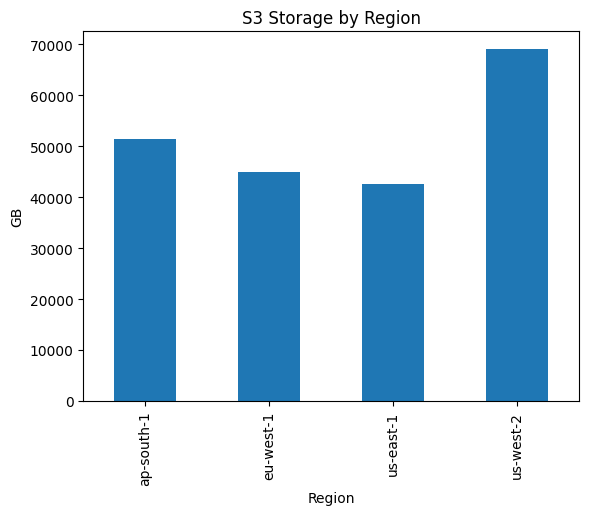

In [7]:
region_storage = s3.groupby('Region')['TotalSizeGB'].sum()

plt.figure()
region_storage.plot(kind='bar')
plt.title('S3 Storage by Region')
plt.ylabel('GB')
plt.show()

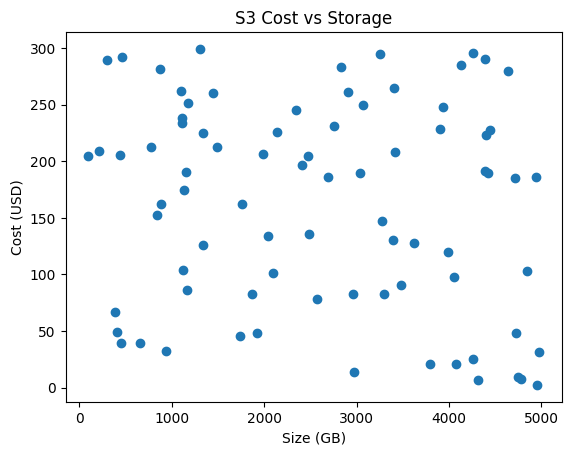

In [10]:
plt.figure()
plt.scatter(s3['TotalSizeGB'], s3['CostUSD'])
plt.title('S3 Cost vs Storage')
plt.xlabel('Size (GB)')
plt.ylabel('Cost (USD)')
plt.show()

In [12]:
ec2.nlargest(5, 'CostUSD')

,ResourceId,ResourceType,Region,CostUSD,Tags,CreationDate,InstanceType,State,CPUUtilization,MemoryUtilization,NetworkIn_Bps,NetworkOut_Bps
89,i-1089,EC2,eu-west-1,1.196,"Owner=Charlie,Environment=Test",2025-09-27,m5.large,terminated,86.48,32.48,364906.0,795472.0
52,i-1052,EC2,us-east-1,1.182,"Owner=David,Environment=Dev",2025-08-27,c5.xlarge,running,37.04,72.17,514475.0,324356.0
85,i-1085,EC2,ap-south-1,1.154,"Owner=Bob,Environment=Prod",2025-07-24,t3.micro,running,54.11,60.20,89614.0,741380.0
31,i-1031,EC2,us-west-2,1.137,"Owner=David,Environment=Dev",2025-05-20,c5.xlarge,running,29.37,19.37,772546.0,285810.0
111,i-1111,EC2,us-west-2,1.136,"Owner=Alice,Environment=Dev",2025-08-28,m5.large,running,77.62,68.06,253185.0,624614.0


In [13]:
s3.nlargest(5, 'TotalSizeGB')

,BucketName,Region,CostUSD,Tags,CreationDate,StorageClass,ObjectCount,TotalSizeGB,VersionEnabled,Encryption
35,bucket-35,us-west-2,31.20,"Owner=David,Purpose=DataLake",2024-10-05,STANDARD,861391,4974.56,True,AES256
19,bucket-19,eu-west-1,2.41,"Owner=David,Purpose=DataLake",2021-10-09,GLACIER,676122,4955.89,False,AES256
5,bucket-5,us-west-2,185.77,"Owner=Bob,Purpose=Logs",2021-01-08,STANDARD,249421,4938.67,False,AES256
32,bucket-32,us-west-2,102.89,"Owner=Alice,Purpose=Backup",2024-06-25,STANDARD,638212,4845.67,False,AES256
52,bucket-52,ap-south-1,7.86,"Owner=David,Purpose=DataLake",2022-07-08,GLACIER,893841,4778.48,False,AES256


In [14]:
ec2.groupby('Region')['CostUSD'].mean()

Region
ap-south-1    0.697061
eu-west-1     0.488714
us-east-1     0.639437
us-west-2     0.554074
Name: CostUSD, dtype: float64

In [15]:
s3.groupby('Region')['TotalSizeGB'].sum()

Region
ap-south-1    51384.50
eu-west-1     44877.65
us-east-1     42534.55
us-west-2     69079.67
Name: TotalSizeGB, dtype: float64